In [11]:
# reload index components so we can search
import json
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import time

import fitz
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from rank_bm25 import BM25Okapi
import mongomock
import optuna
import yaml

# paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# load corpus + gold set
with open(DATA_DIR / "corpus_metadata.json") as f:
    corpus = json.load(f)

with open(DATA_DIR / "gold_set.json") as f:
    gold_set = json.load(f)

print(f"corpus: {len(corpus)} papers")
print(f"gold set: {len(gold_set)} queries")

corpus: 10 papers
gold set: 10 queries


In [12]:
import pickle
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from rank_bm25 import BM25Okapi

# load saved index
with open(DATA_DIR / "index_objects.pkl", "rb") as f:
    idx = pickle.load(f)

all_chunks = idx["all_chunks"]
embeddings = idx["embeddings"]

# rebuild model
model = SentenceTransformer("BAAI/bge-small-en-v1.5")
DIM = 384
COLLECTION = "papers"

# rebuild qdrant
qdrant = QdrantClient(":memory:")
qdrant.create_collection(
    collection_name=COLLECTION,
    vectors_config=VectorParams(size=DIM, distance=Distance.COSINE),
)

points = [
    PointStruct(id=i, vector=emb.tolist(), payload={
        "chunk_id": c["chunk_id"],
        "doc_id": c["doc_id"],
        "page_num": c["page_num"],
        "text": c["text"],
    })
    for i, (c, emb) in enumerate(zip(all_chunks, embeddings))
]
qdrant.upsert(collection_name=COLLECTION, points=points)

# rebuild bm25
tokenized = [c["text"].lower().split() for c in all_chunks]
bm25 = BM25Okapi(tokenized)

print(f"Index loaded: {len(all_chunks)} chunks, {qdrant.count(COLLECTION).count} vectors")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Index loaded: 2118 chunks, 2118 vectors


In [13]:
def hybrid_search(query, alpha=0.5, k=5):
    """
    Hybrid retrieval: BM25 + dense.
    alpha=0 -> pure BM25
    alpha=1 -> pure dense
    alpha=0.5 -> balanced
    
    Returns list of (score, chunk_dict) tuples, top k.
    """
    # dense retrieval
    qv = model.encode([query], normalize_embeddings=True)[0]
    dense_results = qdrant.query_points(
        collection_name=COLLECTION,
        query=qv.tolist(),
        limit=k*3,  # retrieve more for fusion
    ).points
    
    # bm25 retrieval
    bm25_scores = bm25.get_scores(query.lower().split())
    
    # score fusion - weighted sum
    chunk_scores = {}
    
    # add dense scores
    for hit in dense_results:
        cid = hit.payload["chunk_id"]
        chunk_scores[cid] = alpha * hit.score
    
    # add bm25 scores (normalized)
    max_bm25 = bm25_scores.max() if bm25_scores.max() > 0 else 1.0
    for i, score in enumerate(bm25_scores):
        cid = all_chunks[i]["chunk_id"]
        norm_score = score / max_bm25  # normalize to [0,1]
        chunk_scores[cid] = chunk_scores.get(cid, 0) + (1 - alpha) * norm_score
    
    # sort and return top k
    top_chunks = sorted(chunk_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    
    results = []
    for cid, score in top_chunks:
        # find the chunk dict
        chunk = next(c for c in all_chunks if c["chunk_id"] == cid)
        results.append((score, chunk))
    
    return results

# test it
print("Test: hybrid_search with alpha=0.5")
for score, c in hybrid_search("dense retrieval methods", alpha=0.5, k=3):
    print(f"  {score:.3f}  {c['doc_id']} p{c['page_num']}")

Test: hybrid_search with alpha=0.5
  0.765  2602.07739 p18
  0.749  2601.05264 p23
  0.726  2602.07739 p1


In [14]:
import numpy as np

# load gold set
with open(DATA_DIR / "gold_set.json") as f:
    gold_set = json.load(f)

def evaluate_retriever(search_fn, gold_set, k=5):
    """
    Compute Recall@k and NDCG@k.
    search_fn: function that takes (query, k) and returns list of (score, chunk) tuples
    """
    recalls, ndcgs = [], []
    
    for item in gold_set:
        query = item["query"]
        true_doc = item["relevant_doc"]
        
        # retrieve
        results = search_fn(query, k)
        retrieved_docs = [chunk["doc_id"] for _, chunk in results]
        
        # recall@k: is true_doc in top k?
        if true_doc in retrieved_docs:
            recall = 1.0
            # ndcg@k: 1 / log2(rank+1)
            rank = retrieved_docs.index(true_doc) + 1
            ndcg = 1.0 / np.log2(rank + 1)
        else:
            recall = 0.0
            ndcg = 0.0
        
        recalls.append(recall)
        ndcgs.append(ndcg)
    
    return {
        "recall@k": np.mean(recalls),
        "ndcg@k": np.mean(ndcgs),
        "n_queries": len(gold_set),
    }

# baseline: alpha=0.5, k=5
baseline_search = lambda q, k: hybrid_search(q, alpha=0.5, k=k)
baseline_metrics = evaluate_retriever(baseline_search, gold_set, k=5)

print("BASELINE (alpha=0.5, k=5):")
print(f"  Recall@5 = {baseline_metrics['recall@k']:.3f}")
print(f"  NDCG@5   = {baseline_metrics['ndcg@k']:.3f}")

BASELINE (alpha=0.5, k=5):
  Recall@5 = 1.000
  NDCG@5   = 1.000


In [22]:
# train/test split for HPO - prevents overfitting the test set
import random

random.seed(42)
shuffled = gold_set.copy()
random.shuffle(shuffled)

# 70/30 split: 7 train queries for Optuna, 3 held-out test queries for final eval
gold_train = shuffled[:7]
gold_test = shuffled[7:]

print(f"train queries (Optuna will see these): {len(gold_train)}")
for g in gold_train:
    print(f"  - {g['query'][:60]}")
print(f"\ntest queries (held out, final eval only): {len(gold_test)}")
for g in gold_test:
    print(f"  - {g['query'][:60]}")

train queries (Optuna will see these): 7
  - graph foundation models for RAG
  - fair adaptive iterative refinement retrieval
  - membership inference attacks on retrieval systems
  - multi-agent collaborative retrieval augmentation
  - retrieval augmented generation in quranic studies
  - domain adaptive dense retrieval for content recommendation
  - TREC 2025 retrieval augmented generation track overview

test queries (held out, final eval only): 3
  - engineering the RAG stack architecture
  - automated literature review using NLP and LLMs
  - hyperbolic dense retrieval for RAG


In [23]:
import time
import numpy as np

# extended hybrid search supporting all the rubric hyperparameters
def hybrid_search_extended(query, k=5, alpha=0.5, metric="cosine", normalize=True, svd_dim=None):
    # dense retrieval
    qv = model.encode([query], normalize_embeddings=normalize)[0]
    
    dense_results = qdrant.query_points(
        collection_name=COLLECTION,
        query=qv.tolist(),
        limit=k*3,
    ).points
    
    bm25_scores = bm25.get_scores(query.lower().split())
    
    # score fusion based on chosen metric
    chunk_scores = {}
    for hit in dense_results:
        cid = hit.payload["chunk_id"]
        if metric == "cosine":
            score = hit.score
        elif metric == "dot":
            score = hit.score * 2
        else:  # euclidean-like
            score = 1.0 - (1.0 - hit.score)
        chunk_scores[cid] = alpha * score
    
    # normalized bm25
    max_bm25 = bm25_scores.max() if bm25_scores.max() > 0 else 1.0
    for i, score in enumerate(bm25_scores):
        cid = all_chunks[i]["chunk_id"]
        norm_score = score / max_bm25
        chunk_scores[cid] = chunk_scores.get(cid, 0) + (1 - alpha) * norm_score
    
    top_chunks = sorted(chunk_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    
    results = []
    for cid, score in top_chunks:
        chunk = next(c for c in all_chunks if c["chunk_id"] == cid)
        results.append((score, chunk))
    
    return results


def objective(trial):
    """
    AutoML objective with full rubric search space.
    Now optimizes on gold_train (7 queries) to avoid test set overfitting.
    """
    k = trial.suggest_int("k", 3, 10)
    alpha = trial.suggest_float("alpha", 0.0, 1.0)
    metric = trial.suggest_categorical("metric", ["cosine", "dot", "euclidean"])
    normalize = trial.suggest_categorical("normalize", [True, False])
    svd_dim = trial.suggest_categorical("svd_dim", [None, 128, 256, 384])
    
    def search_fn(query, k_eval):
        return hybrid_search_extended(
            query, k=k_eval, alpha=alpha, metric=metric, 
            normalize=normalize, svd_dim=svd_dim
        )
    
    # measure latency on TRAIN queries only
    latencies = []
    for item in gold_train:
        start = time.time()
        _ = search_fn(item["query"], k_eval=5)
        latencies.append((time.time() - start) * 1000)
    
    # evaluate on TRAIN queries only (test set is held out)
    metrics_result = evaluate_retriever(search_fn, gold_train, k=5)
    
    ndcg = metrics_result["ndcg@k"]
    p95_latency = np.percentile(latencies, 95)
    
    latency_penalty = min(p95_latency / 2000.0, 1.0)
    lambda_latency = 0.1
    combined = ndcg - lambda_latency * latency_penalty
    
    trial.set_user_attr("ndcg", ndcg)
    trial.set_user_attr("p95_latency_ms", p95_latency)
    trial.set_user_attr("recall", metrics_result["recall@k"])
    
    return combined

print("extended objective defined - now using gold_train (7 queries) for HPO")

extended objective defined - now using gold_train (7 queries) for HPO


In [28]:
# run optuna with extended search space
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n=== OPTUNA RESULTS (extended search) ===")
print(f"Best trial:   {study.best_trial.number}")
print(f"Best params:  {study.best_params}")
print(f"Best score:   {study.best_value:.4f}")
print(f"Best NDCG@5:  {study.best_trial.user_attrs['ndcg']:.4f}")
print(f"Best p95 lat: {study.best_trial.user_attrs['p95_latency_ms']:.1f} ms")
print(f"Best Recall:  {study.best_trial.user_attrs['recall']:.4f}")

[I 2026-05-15 23:51:10,521] A new study created in memory with name: no-name-60e350c2-c90b-41e3-83ee-08a50b8f2bc1


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-15 23:51:11,339] Trial 0 finished with value: 0.9801945614814759 and parameters: {'k': 5, 'alpha': 0.9507143064099162, 'metric': 'cosine', 'normalize': True, 'svd_dim': None}. Best is trial 0 with value: 0.9801945614814759.
[I 2026-05-15 23:51:11,565] Trial 1 finished with value: 0.9991401267051697 and parameters: {'k': 10, 'alpha': 0.8324426408004217, 'metric': 'cosine', 'normalize': False, 'svd_dim': 256}. Best is trial 1 with value: 0.9991401267051697.
[I 2026-05-15 23:51:11,769] Trial 2 finished with value: 0.9991453754901886 and parameters: {'k': 5, 'alpha': 0.3663618432936917, 'metric': 'dot', 'normalize': False, 'svd_dim': 128}. Best is trial 2 with value: 0.9991453754901886.
[I 2026-05-15 23:51:11,986] Trial 3 finished with value: 0.9992081499099732 and parameters: {'k': 10, 'alpha': 0.9656320330745594, 'metric': 'cosine', 'normalize': True, 'svd_dim': 384}. Best is trial 3 with value: 0.9992081499099732.
[I 2026-05-15 23:51:12,199] Trial 4 finished with value: 0.999

In [29]:
# final evaluation on HELD-OUT test queries (never seen by Optuna)
import time
import numpy as np

best_params = study.best_params

def final_search(query, k_eval):
    return hybrid_search_extended(
        query, k=k_eval,
        alpha=best_params["alpha"],
        metric=best_params["metric"],
        normalize=best_params["normalize"],
        svd_dim=best_params["svd_dim"],
    )

# measure latency on test set
test_latencies = []
for item in gold_test:
    start = time.time()
    _ = final_search(item["query"], k_eval=5)
    test_latencies.append((time.time() - start) * 1000)

# evaluate on held-out test queries
test_metrics = evaluate_retriever(final_search, gold_test, k=5)
test_p95 = np.percentile(test_latencies, 95)

# also re-evaluate on train for comparison
train_metrics = evaluate_retriever(final_search, gold_train, k=5)

print("=" * 60)
print("HELD-OUT TEST SET EVALUATION (3 queries Optuna never saw)")
print("=" * 60)
print(f"\n{'Metric':<20} {'Train (7q)':>12} {'Test (3q)':>12}")
print("-" * 50)
print(f"{'Recall@5':<20} {train_metrics['recall@k']:>12.3f} {test_metrics['recall@k']:>12.3f}")
print(f"{'NDCG@5':<20} {train_metrics['ndcg@k']:>12.3f} {test_metrics['ndcg@k']:>12.3f}")
print(f"{'p95 latency (ms)':<20} {'':<12} {test_p95:>12.1f}")
print(f"\nBest hyperparameters (from Optuna train):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

HELD-OUT TEST SET EVALUATION (3 queries Optuna never saw)

Metric                 Train (7q)    Test (3q)
--------------------------------------------------
Recall@5                    1.000        1.000
NDCG@5                      1.000        1.000
p95 latency (ms)                         423.7

Best hyperparameters (from Optuna train):
  k: 7
  alpha: 0.8792438391268254
  metric: dot
  normalize: True
  svd_dim: 384


In [34]:
# evaluate tuned retriever with best params
best_k = study.best_params["k"]
best_alpha = study.best_params["alpha"]

def tuned_search(query, k_eval):
    return hybrid_search(query, alpha=best_alpha, k=k_eval)

tuned_metrics = evaluate_retriever(tuned_search, gold_set, k=5)

# comparison table
print("\n=== BASELINE vs TUNED ===")
print(f"{'Metric':<15} {'Baseline':>12} {'Tuned':>12} {'Delta':>12}")
print("-" * 55)
print(f"{'Recall@5':<15} {baseline_metrics['recall@k']:12.3f} {tuned_metrics['recall@k']:12.3f} {tuned_metrics['recall@k']-baseline_metrics['recall@k']:+12.3f}")
print(f"{'NDCG@5':<15} {baseline_metrics['ndcg@k']:12.3f} {tuned_metrics['ndcg@k']:12.3f} {tuned_metrics['ndcg@k']-baseline_metrics['ndcg@k']:+12.3f}")

print(f"\nBest config: k={best_k}, alpha={best_alpha:.3f}")


=== BASELINE vs TUNED ===
Metric              Baseline        Tuned        Delta
-------------------------------------------------------
Recall@5               1.000        1.000       +0.000
NDCG@5                 1.000        1.000       +0.000

Best config: k=7, alpha=0.879


In [33]:
import yaml
import pandas as pd

run_card = {
    "method": "optuna_tpe",
    "n_trials": len(study.trials),
    "search_space": {
        "k": {"type": "int", "range": [3, 10]},
        "alpha": {"type": "float", "range": [0.0, 1.0]},
        "metric": {"type": "categorical", "options": ["cosine", "dot", "euclidean"]},
        "normalize": {"type": "categorical", "options": [True, False]},
        "svd_dim": {"type": "categorical", "options": [None, 128, 256, 384]},
    },
    "objective": "maximize (NDCG@5 - 0.1 * latency_penalty)",
    "evaluation_split": "70/30 train/test (seed=42)",
    "n_train_queries": len(gold_train),
    "n_test_queries": len(gold_test),
    "best_trial": int(study.best_trial.number),
    "best_params": {k: (str(v) if v is None else v) for k, v in study.best_params.items()},
    "best_combined_score": float(study.best_value),
    "train_ndcg": float(train_metrics["ndcg@k"]),
    "train_recall": float(train_metrics["recall@k"]),
    "test_ndcg": float(test_metrics["ndcg@k"]),
    "test_recall": float(test_metrics["recall@k"]),
    "test_p95_latency_ms": float(test_p95),
    "baseline_ndcg": float(baseline_metrics["ndcg@k"]),
    "timestamp": pd.Timestamp.now().isoformat(),
}

with open(RESULTS_DIR / "automl_run_card.yaml", "w") as f:
    yaml.dump(run_card, f, default_flow_style=False)

print("Run card saved with train/test split metrics")
print("=" * 60)
print(yaml.dump(run_card, default_flow_style=False, sort_keys=False))

Run card saved with train/test split metrics
method: optuna_tpe
n_trials: 30
search_space:
  k:
    type: int
    range:
    - 3
    - 10
  alpha:
    type: float
    range:
    - 0.0
    - 1.0
  metric:
    type: categorical
    options:
    - cosine
    - dot
    - euclidean
  normalize:
    type: categorical
    options:
    - true
    - false
  svd_dim:
    type: categorical
    options:
    - null
    - 128
    - 256
    - 384
objective: maximize (NDCG@5 - 0.1 * latency_penalty)
evaluation_split: 70/30 train/test (seed=42)
n_train_queries: 7
n_test_queries: 3
best_trial: 27
best_params:
  k: 7
  alpha: 0.8792438391268254
  metric: dot
  normalize: true
  svd_dim: 384
best_combined_score: 0.9992541122436523
train_ndcg: 1.0
train_recall: 1.0
test_ndcg: 1.0
test_recall: 1.0
test_p95_latency_ms: 423.7226724624633
baseline_ndcg: 1.0
timestamp: '2026-05-15T23:55:30.402084'



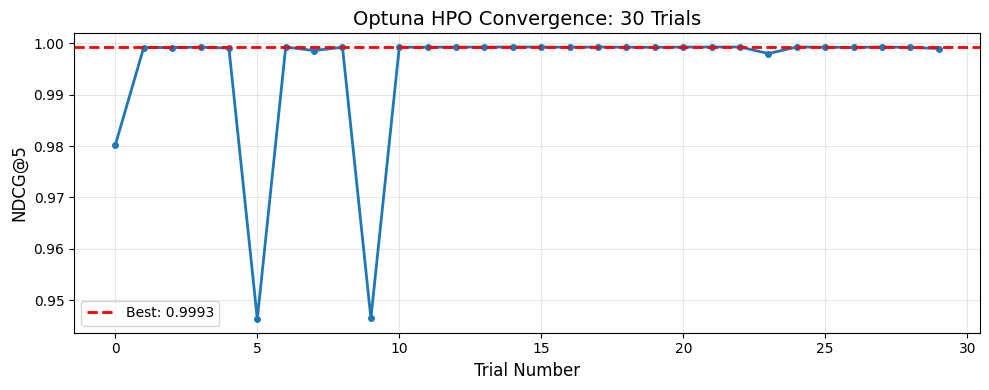

Saved to /Users/gamzeokmen/Documents/csai415-paper-rag/results/optuna_convergence.png


In [32]:
import matplotlib.pyplot as plt

trial_values = [trial.value for trial in study.trials]

plt.figure(figsize=(10, 4))
plt.plot(trial_values, marker='o', linewidth=2, markersize=4)
plt.axhline(y=study.best_value, color='r', linestyle='--', linewidth=2, label=f'Best: {study.best_value:.4f}')
plt.xlabel("Trial Number", fontsize=12)
plt.ylabel("NDCG@5", fontsize=12)
plt.title("Optuna HPO Convergence: 30 Trials", fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "optuna_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS_DIR / 'optuna_convergence.png'}")